# 決定木を用いたIrisデータセットの分類と可視化

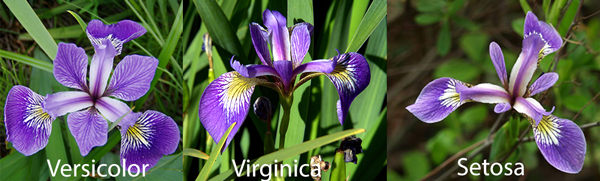

## 環境設定とデータ準備：

In [31]:
# irisのデータセットはskleanパッケージからロードする
from sklearn.datasets import load_iris

# Irisデータセットの読み込み
iris = load_iris()
X, y = iris.data, iris.target

## 決定木モデルの構築

In [ ]:
# データセットを分割する関数をロードする
from sklearn.model_selection import train_test_split
# 決定木のクラスをロードする
from sklearn.tree import DecisionTreeClassifier

# データの分割（30%はテストデータ、残りは訓練データ）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# モデルの構築（深さ=5）
model= DecisionTreeClassifier(max_depth=5)
# モデルの学習（学習データ）
model.fit(X_train, y_train)

## モデルの性能評価

In [ ]:
# 正解率、適合率、再現率、そしてf1スコアの評価指標関数をロードする
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 混同行列の可視化
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 予測（テストデータ）
y_pred = model.predict(X_test)
# 評価：
#   データセットが多クラス分類で、各クラスのデータ数がバランスしている場合は、
#   precision_score()、recall_score()、f1_score()を使うときにaverageパラメータに 
#   'macro' を渡す必要がある。
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 結果の表示
print(f"正解率 (Accuracy): {accuracy:.4f}")
print(f"適合率 (Precision): {precision:.4f}")
print(f"再現率 (Recall): {recall:.4f}")
print(f"F1スコア (F1-Score): {f1:.4f}")

# 混同行列を用いて，分類結果を可視化してください。
cm = confusion_matrix(y_test, y_pred)
print("混同行列:")
print(cm)

# 混同行列の可視化
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## 決定木の深さによる性能変化の分析

In [ ]:
# グラフを可視化するmatplotlibのパッケージをロードする
import matplotlib.pyplot as plt
# import japanize_matplotlib

# 決定木の深さを1から11までに指定する
# 深さを 1、2、4、8、16、32、64 に設定したい場合は、Python のリストを使う
# 例：max_depths = [1, 2, 4, 8, 16, 32, 64]
max_depths = range(1, 11)

# 各深さで得られたテストデータの正解率を格納するために、リストを使う
accuracies = []

# forループ使って各深さで決定木の性能を測定して...
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # その結果はaccuraciesリストに格納する
    accuracies.append(accuracy_score(y_test, y_pred))

# 得た結果はグラフとして可視化する
# plot(x軸, y軸)
plt.plot(max_depths, accuracies)
# x軸のラベル
plt.xlabel('Max Depth')
# y軸のラベル
plt.ylabel('Accuracy')
# プロットのラベル
plt.title('Accuracy vs Max Depth')
# グラフの表示
plt.show()

## 最適な決定木の可視化と解釈

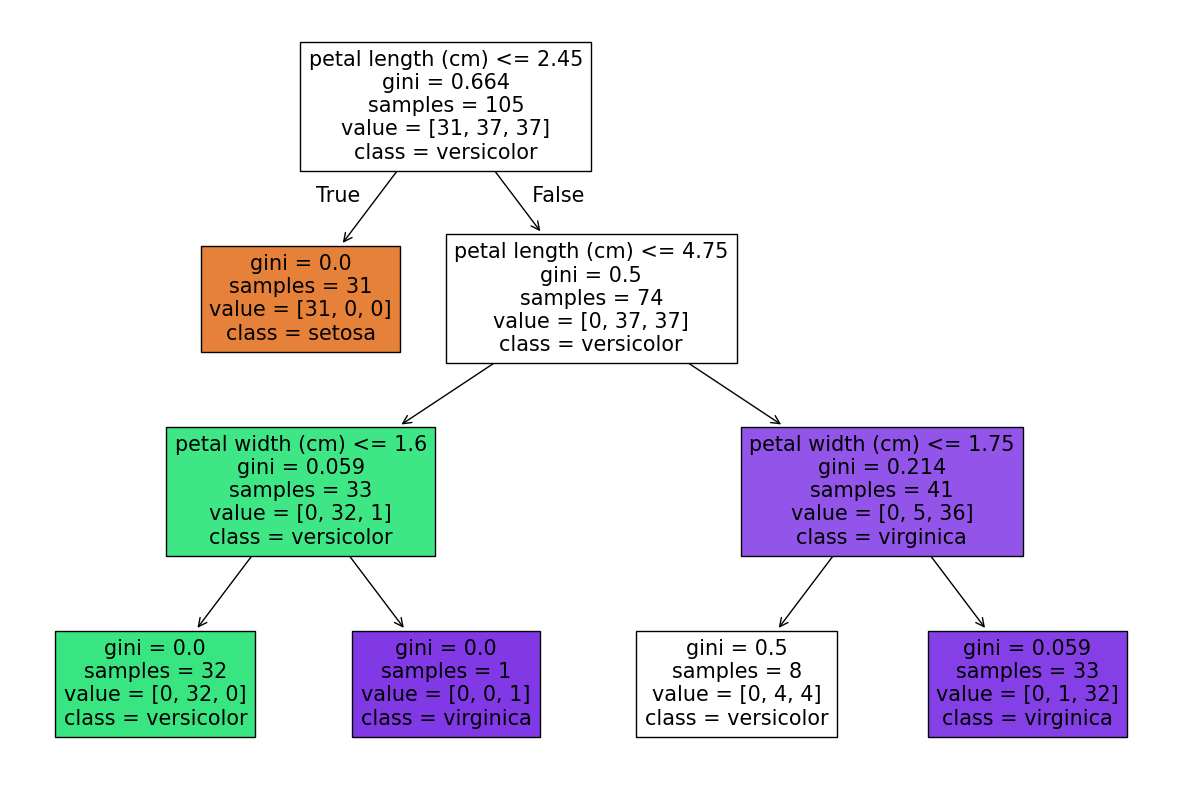


特徴量の重要度:
             Feature  Importance
2  petal length (cm)    0.925108
3   petal width (cm)    0.074892
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


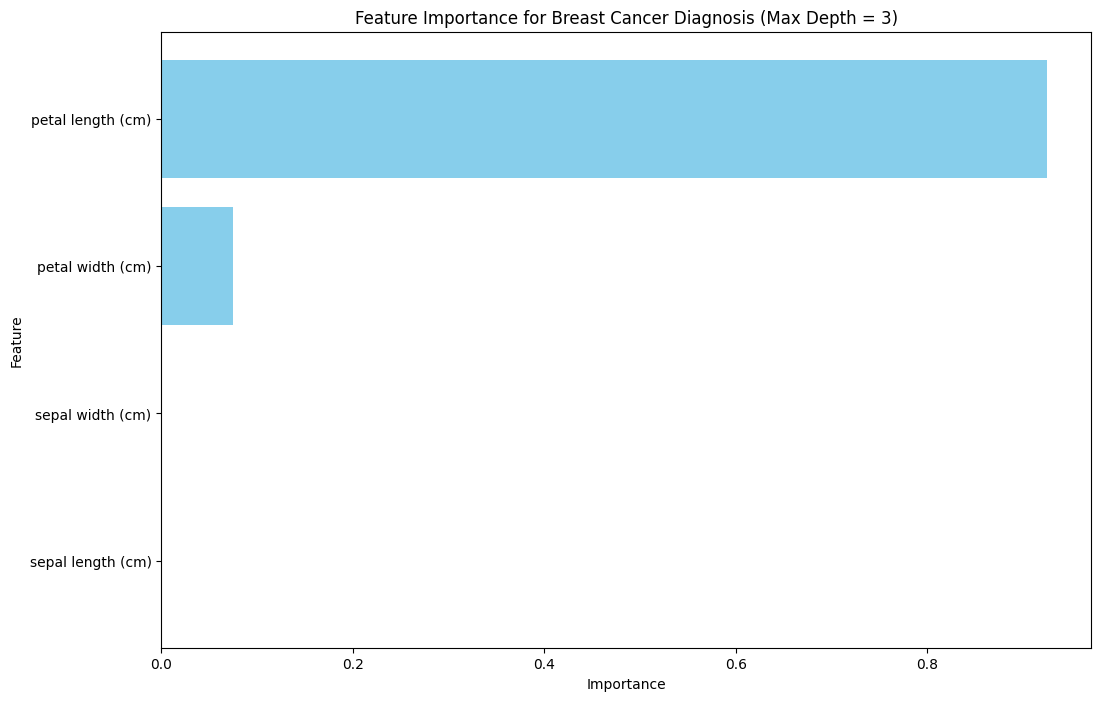

In [56]:
# 決定木の可視化
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# pandasでの計算
import pandas as pd

# グラフでは最適な決定木の深さは3
optimized_depth = 3

# 再度学習する
model = DecisionTreeClassifier(max_depth=optimized_depth, random_state=42)
model.fit(X_train, y_train)

# 決定木の可視化
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

# 特徴量重要度の取得
feature_importances = model.feature_importances_

# 特徴量の名称と重要度を対応付ける
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': feature_importances
})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n特徴量の重要度:")
print(importance_df)

# 特徴量の重要度を可視化
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Feature Importance for Breast Cancer Diagnosis (Max Depth = {optimized_depth})')
plt.gca().invert_yaxis() # 重要度が高いものが上に来るようにする
plt.show()
